# Respiratory rate estimation

## Introduction

Physiological activity generates subtle mechanical movements that propagate throughout the body and can be detected externally. These include vibrations produced by the cardiovascular system during cardiac contraction and relaxation, valve opening and closure, blood flow recoil and the lower-frequency chest wall expansion due to respiration.

These physiological motions can be captured using non-invasive sensing techniques, providing information that can be used for health monitoring and clinical assessment [citations]. Seismocardiography (SCG) measures local chest wall vibrations at the skin surface, typically over the sternum, whereas Ballistocardiography (BCG) captures body displacements detectable through sensors embedded in a bed, chair, or scale.

In this project, the respiratory rate (RR) of two healthy individuals is estimated using inertial data acquired from an Inertial Measurement Unit (IMU) called MuSe. In the first dataset, a Muse_2128 v2 BC device is positioned at the center of the sternum. In the second dataset, a Muse_2168 v2 BC device is placed where?
The device configurations are as follows (parameter definitions are detailed in subsequent sections):
Dataset 1: 500 dps, 2 g, 12 G, 100 g, high resolution, 200 Hz sampling rate.
Dataset 2: 4000 dps, 2 g, 12 G, 100 g, high resolution, 100 Hz sampling rate.

Due to the non-sinusoidal nature of the recorded signals, RR is extracted in the time domain after appropriate signal preprocessing and cleaning. Three methods are illustrated to denoise the signal: inverse Fourier method, digital filtering, and wavelet transforms.


## Data presentation and preliminary analysis

The MuSe platform records linear acceleration, angular velocity, orientation (expressed as quaternions), and magnetic field measurements. To ensure measurement accuracy, sensor calibration must be applied. The calibration parameters, provided in the file README1.txt and README5.txt, are used to correct the raw signals prior to analysis.

We begin with the first dataset by loading the data into a pandas DataFrame, applying the calibration parameters, and displaying a subset of the data.

In [31]:
# =========================
# Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.signal import detrend, butter, filtfilt
from scipy.fft import fft, fftfreq, ifft
import seaborn as sns

# =========================
# Calibration Parameters
# =========================

# --- Dataset 1 (center_sternum) ---
ds1_gyro_matrix = np.eye(3)
ds1_gyro_offset = np.array([-2.242224,  2.963463, -0.718397])

ds1_acc_matrix = np.array([
    [ 1.000966,  -0.002326418, -0.0006995499],
    [-0.002326379, 0.9787045,  -0.001540918 ],
    [-0.0006995811,-0.001540928, 1.00403    ]
])
ds1_acc_offset = np.array([-3.929942, -13.74679, 60.67546])

ds1_magn_matrix = np.array([
    [ 0.9192851, -0.02325168,  0.003480837],
    [-0.02325175, 0.914876,    0.004257396],
    [ 0.003481006,0.004257583, 0.8748001  ]
])
ds1_magn_offset = np.array([-95.67974, -244.9142, 17.71132])


# --- Dataset 2 (??)---
ds2_gyro_matrix = np.eye(3)
ds2_gyro_offset = np.array([-2.804399,  1.793105,  0.3411708])

ds2_acc_matrix = np.array([
    [1.002982,   9.415505e-05,  0.004346743],
    [9.04459e-05,1.002731,     -0.001444198],
    [0.004346536,-0.001444751,  1.030587   ]
])
ds2_acc_offset = np.array([3.602701, -20.96658, 54.97186])

ds2_magn_matrix = np.array([
    [ 1.013437,  -0.04728858, -0.001861475],
    [-0.04728862, 1.004832,    0.008222118],
    [-0.001861605,0.008221965, 0.9439077  ]
])
ds2_magn_offset = np.array([-150.4098, 74.62431, 630.9805])



def load_dataset(filename):
    return pd.read_csv(
        filename,
        delimiter="\t",
        dtype={
            "LogMode": int,
            "LogFreq": int,
            "Timestamp": int,
            "AccX": float, "AccY": float, "AccZ": float,
            "GyroX": float, "GyroY": float, "GyroZ": float,
            "MagnX": float, "MagnY": float, "MagnZ": float,
        },
    )


def calibrate_data(df, cols, matrix, offset):
    """
    Apply in-place calibration to 3-axis sensor data according to y = M x + b

    Parameters
    ----------
    df : DataFrame
        Input data.
    cols : list[str]
        Three column names (e.g., ["AccX","AccY","AccZ"]).
    matrix : (3x3) array-like
        Calibration matrix.
    offset : (3,) array-like
        Offset vector.
    """
    if len(cols) != 3:
        raise ValueError("Exactly three columns must be specified.")

    M = np.asarray(matrix, dtype=float)
    b = np.asarray(offset, dtype=float)

    if M.shape != (3, 3):
        raise ValueError("Calibration matrix must be 3x3.")
    if b.shape != (3,):
        raise ValueError("Offset vector must have length 3.")

    X = df[cols].to_numpy()
    df.loc[:, cols] = X @ M.T + b


# =========================
# Load and Calibrate Dataset 1
# =========================

df1 = load_dataset("center_sternum.txt")

calibrate_data(df1, ["AccX",  "AccY",  "AccZ"],  ds1_acc_matrix,  ds1_acc_offset)
calibrate_data(df1, ["GyroX", "GyroY", "GyroZ"], ds1_gyro_matrix, ds1_gyro_offset)
calibrate_data(df1, ["MagnX", "MagnY", "MagnZ"], ds1_magn_matrix, ds1_magn_offset)

display(df1)


,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,200,1576222772,943.007996,410.325442,130.264244,-9.066652,-11.280817,0.686183,-502.261441,-683.404962,-141.669690,0.792622,0.254952,-0.553850,-0.000031
1,5,200,1576222772,965.209969,363.380701,148.635086,3.940982,-9.326617,-8.687863,-502.257960,-683.400705,-140.794890,0.736461,0.275124,-0.617969,0.006806
2,5,200,1576222772,985.689106,356.065246,138.465450,9.467696,-1.998369,-8.168779,-502.257960,-683.400705,-140.794890,0.729465,0.275246,-0.626118,0.009827
3,5,200,1576222772,950.852176,393.026437,148.047237,15.635636,5.482547,-6.703130,-502.207976,-685.226199,-139.928605,0.723413,0.277200,-0.632221,0.011383
4,5,200,1576222772,968.040164,402.461108,159.595720,22.979146,8.368043,3.296870,-502.207976,-685.226199,-139.928605,0.721948,0.280007,-0.632679,0.010193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16501,5,200,1576222847,954.849739,269.000099,5.047576,-0.578102,5.268807,-1.390153,-539.805161,-644.743591,-96.144764,0.650810,0.379162,-0.636402,0.166356
16502,5,200,1576222847,951.006879,266.016847,9.709647,-0.761308,5.452013,-1.420687,-539.778428,-645.654210,-95.274222,0.650239,0.379803,-0.636708,0.165960
16503,5,200,1576222847,963.711402,268.397270,-4.573267,-1.127720,6.337509,-1.619160,-539.778428,-645.654210,-95.274222,0.649365,0.380627,-0.637227,0.165502
16504,5,200,1576222847,961.972293,278.538659,3.067677,-1.539934,6.627585,-2.306183,-540.740736,-643.796949,-94.394388,0.648973,0.381329,-0.637348,0.164953


All datasets share the same column structure, which is described below.

**LogMode** indicates the device logging configuration. For this analysis we ensure it is constant and equal to 5.

**LogFreq** specifies the nominal sampling frequency in Hz selected during acquisition. This value is constant within each dataset.

**Timestamp** is an integer representing the date and time at which the sample is recorded.

Due to buffering or transmission effects, the number of samples associated with each Timestamp does not strictly equal LogFreq, as illustrated in the following plot for dataset 1. Because LogFreq represents the device's configured sampling rate, it is considered the more reliable reference for reconstructing a uniform time base.
Accordingly, LogMode, LogFreq, and Timestamp are removed, and a new Time column is generated based on LogFreq.

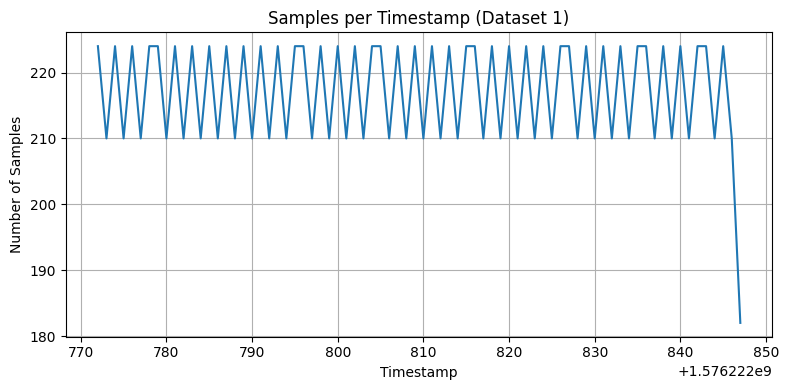

In [ ]:
def preprocess_time_metadata(df):
    """
    Validate logging configuration and construct a uniform time base.

    - Ensures Log Mode is 5.
    - Ensures Log Freq is constant.
    - Creates a time column in seconds (starting at 0).
    - Drops Log Mode, Log Freq, and Timestamp columns.
    """
    if not (df['Log Mode'] == 5).all():
        raise ValueError("Unsupported Log Mode")

    log_freq = df["Log Freq"].iloc[0]
    if not (df['Log Freq'] == log_freq).all():
        raise ValueError("Log frequency is not constant")

    df.drop(columns=['Log Mode', 'Log Freq', 'Timestamp'], inplace=True)
    df['Time'] = df.index / log_freq
    return log_freq
    

# Count number of samples per timestamp
entries_count = df1.groupby('Timestamp').size()

# Plot them
plt.figure(figsize=(8, 4))
plt.plot(entries_count.index, entries_count.values)
plt.xlabel('Timestamp')
plt.ylabel('Number of Samples')
plt.title('Samples per Timestamp (Dataset 1)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Create Time column
ds1_log_freq = preprocess_time_metadata(df1)


**AccX**, **AccY**, **AccZ** represent linear acceleration measured along three orthogonal axes, expressed in milli-g.

**GyroX**, **GyroY**, **GyroZ** represent angular velocity along three orthogonal axes, expressed in degrees per second (dps).

**MagnX**, **MagnY**, **MagnZ** represent magnetic field components along three orthogonal axes, expressed in milligauss.

**qw**, **qi**, **qj**, **qk** are the normalized quaternion components describing the sensor orientation.

The accelerometer, gyroscope, and magnetometer are physically independent sensors, each operating within its own three-axis reference frame. The quaternion components are likely derived from accelerometer and gyroscope data and therefore do not constitute independent physical measurements. Consequently, they are excluded from further analysis.

The script animation.py visualizes the orientation vectors computed from the quaternions, together with the acceleration, angular velocity, and magnetic field vectors.

In [33]:
# Drop quaternions components
df1.drop(columns=['qw', 'qi', 'qj', 'qk'], inplace=True)

At the beginning and end of the recording, the signal contains artifacts caused by sensor placement and removal. These segments are excluded from the analysis.

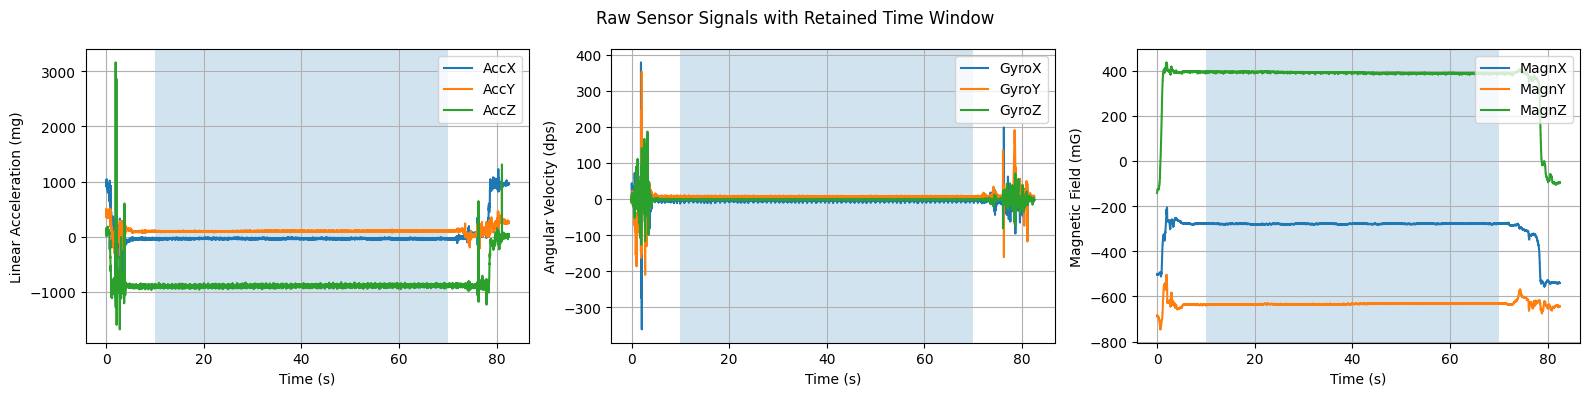

In [ ]:
def trim(df, start_time, end_time):
    mask = (df['Time'] >= start_time) & (df['Time'] < end_time)
    df.drop(df.index[~mask], inplace=True)

# Time window to retain (seconds)
start_time, end_time = 10, 70

# Plot raw signals with highlighted retained region
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4), sharex=True)
label_columns_pairs = {
    "Linear Acceleration (mg)": ["AccX", "AccY", "AccZ"],
    "Angular Velocity (dps)": ["GyroX", "GyroY", "GyroZ"],
    "Magnetic Field (mG)": ["MagnX", "MagnY", "MagnZ"],
}
for axis, (y_label, columns) in zip(axes, label_columns_pairs.items()):
    for column_name in columns:
        axis.plot(df1["Time"], df1[column_name], label=column_name)

    # Highlight retained time window
    axis.axvspan(start_time, end_time, alpha=0.2)

    axis.set_xlabel("Time (s)")
    axis.set_ylabel(y_label)
    axis.legend(loc="upper center")
    axis.grid(True)

fig.suptitle("Raw Sensor Signals with Retained Time Window")
plt.tight_layout()
plt.show()

trim(df1, start_time, end_time)

Principal Component Analysis (PCA) is applied separately to the linear acceleration, gyroscope, and magnetic field measurements in order to transform each sensor’s three-axis data into a more informative basis than the original arbitrary sensor reference frame.

Variability of AccPC: [0.77155797 0.13962116 0.08882087]
Variability of GyroPC: [0.80437035 0.15928114 0.03634851]
Variability of MagnPC: [0.78870295 0.1204547  0.09084235]


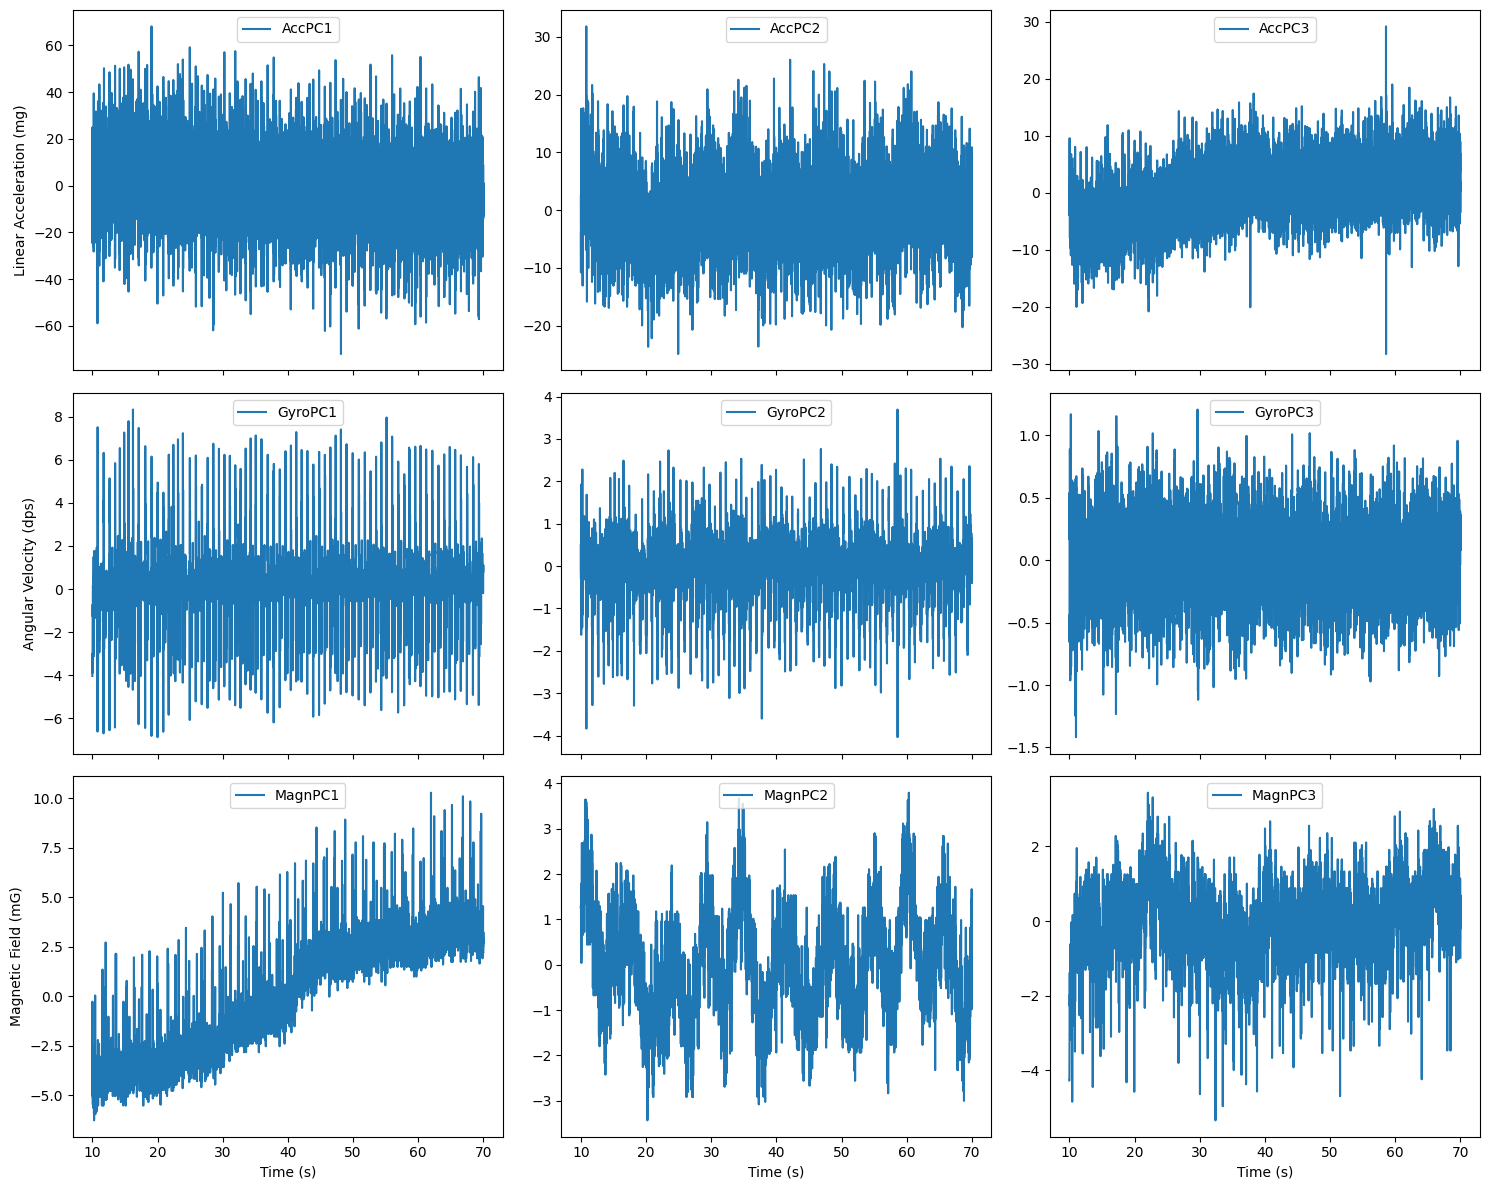

In [ ]:
def pca(df, columns):
    '''
    Apply PCA to the given dataframe and columns using SVD.
    
    Parameters:
    df: the dataframe to modify
    columns: the columns to apply PCA to
    
    Returns:
    variability: the variability of each principal component (descending order)
    principal_axes: the principal components ordered by variability (descending order)
    '''
    
    X = df[columns].to_numpy()
    N = X.shape[0]

    X_centered = X - np.mean(X, axis=0)

    U, sigma, Vt = svd(X_centered)
    
    eigenvalues = (sigma**2) / (N - 1)
    cov_trace = np.sum(eigenvalues)
    variability = eigenvalues / cov_trace
    
    pc = Vt.T
    
    projected_data = np.dot(X_centered, pc)

    # Drop the original columns used for PCA
    df.drop(columns=columns, inplace=True)

    prefix = columns[0][:-1]
    pc_columns = [f'{prefix}PC{i+1}' for i in range(X.shape[1])]
    
    # Replace the original columns with the PCA projections and drop the old columns
    for i, pc_col in enumerate(pc_columns):
        df[pc_col] = projected_data[:, i]
    
    return variability, pc

# Apply PCA to each sensor data
variability_acc, pc_acc = pca(df1, ['AccX', 'AccY', 'AccZ'])
print(f'Variability of AccPC: {variability_acc}')

variability_gyro, pc_gyro = pca(df1, ['GyroX', 'GyroY', 'GyroZ'])
print(f'Variability of GyroPC: {variability_gyro}')

variability_magn, pc_magn = pca(df1, ['MagnX', 'MagnY', 'MagnZ'])
print(f'Variability of MagnPC: {variability_magn}')

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
axes = axes.flatten()
label_columns_pairs = {
    "Linear Acceleration (mg)": ["AccPC1", "AccPC2", "AccPC3"],
    "Angular Velocity (dps)": ["GyroPC1", "GyroPC2", "GyroPC3"],
    "Magnetic Field (mG)": ["MagnPC1", "MagnPC2", "MagnPC3"],
}
for i, (ylabel, cols) in enumerate(label_columns_pairs.items()):
    for j, col in enumerate(cols):
        ax = axes[i * 3 + j]
        ax.plot(df1["Time"], df1[col], label=col)
        
        # Set y-axis label only on the leftmost column
        if j == 0:
            ax.set_ylabel(ylabel)
        
        # Set x-axis label only on the bottommost row
        if i == 2:
            ax.set_xlabel("Time (s)")
        
        # Set legend for each subplot
        ax.legend(loc="upper center")

plt.tight_layout()
plt.show()


To explore the relationships between the sensor measurements, we plot the pairwise relationships between the columns using a pairplot. This helps us identify any potential linear correlations between these features. We also compute basic descriptive statistics for a more detailed summary of the data.

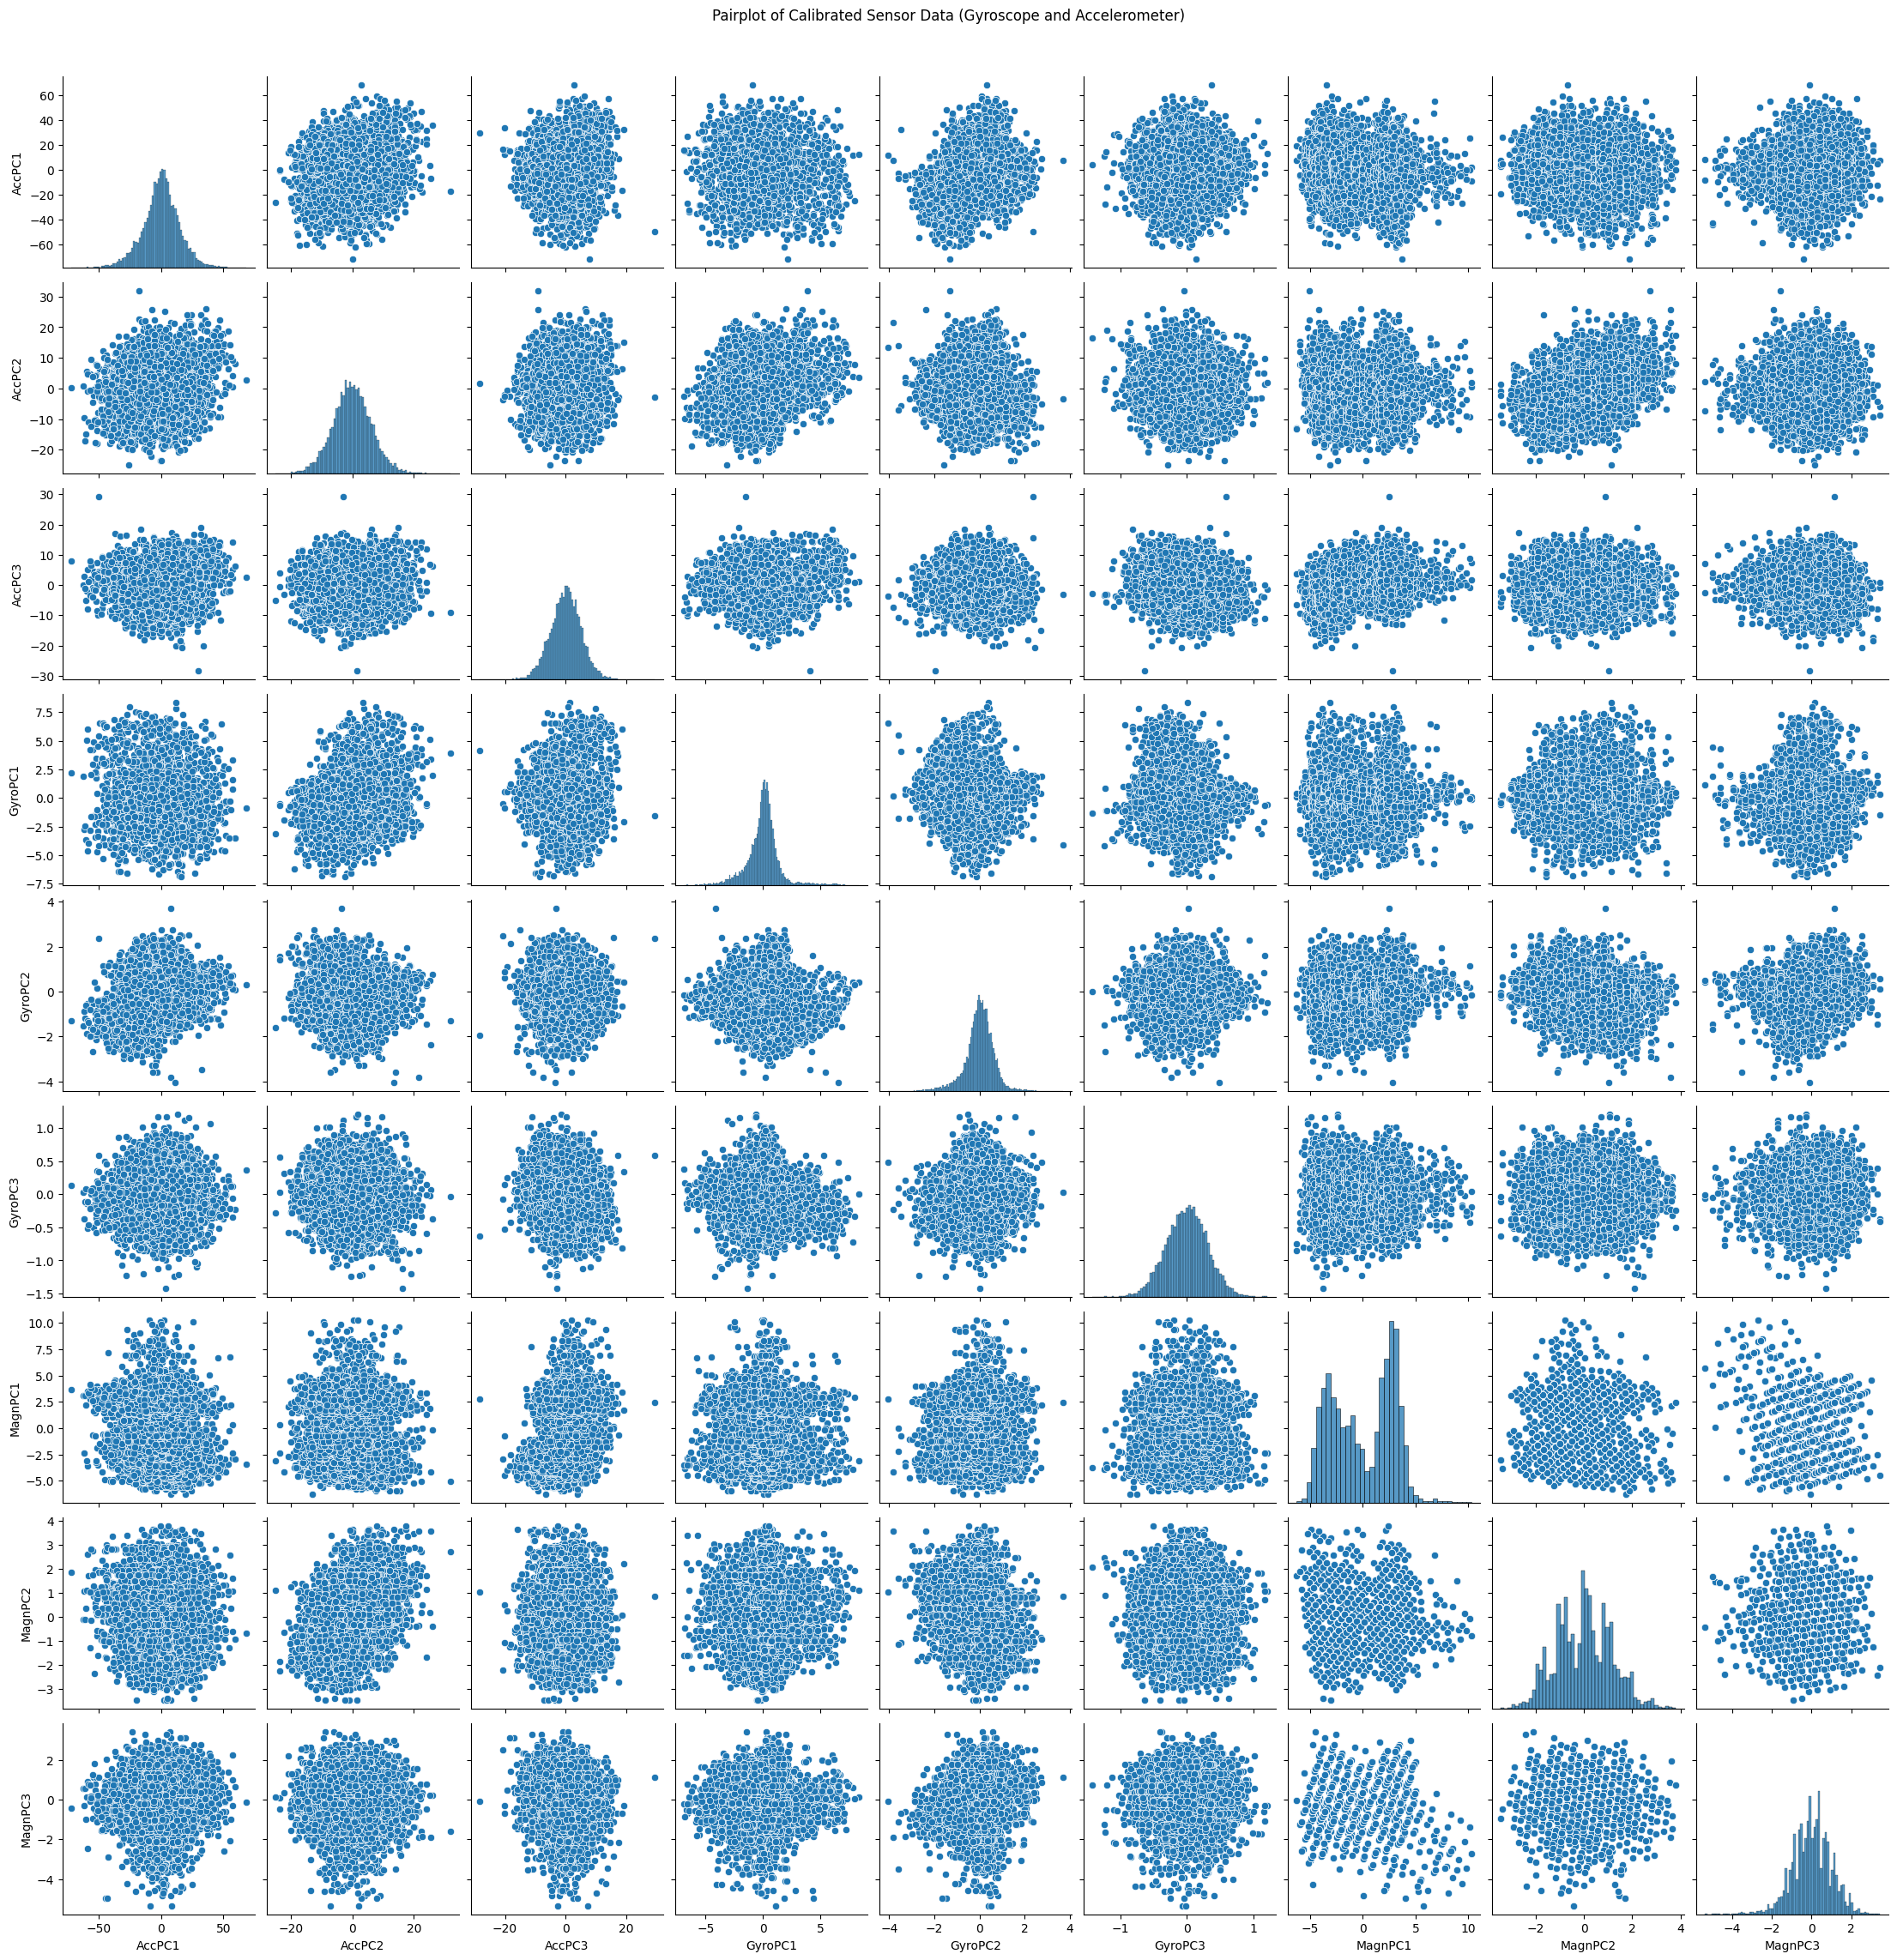

,Time,AccPC1,AccPC2,AccPC3,GyroPC1,GyroPC2,GyroPC3,MagnPC1,MagnPC2,MagnPC3
count,12000.00000,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04
mean,39.99750,-9.398112e-15,-5.002221e-15,-1.515825e-16,-3.457975e-16,1.894781e-17,-1.740830e-16,-6.669628e-15,-1.055393e-14,-4.871481e-14
std,17.32123,1.484015e+01,6.312910e+00,5.035139e+00,1.456208e+00,6.480036e-01,3.095555e-01,2.912245e+00,1.138107e+00,9.883604e-01
min,10.00000,-7.200896e+01,-2.494085e+01,-2.828743e+01,-6.871670e+00,-4.039614e+00,-1.417993e+00,-6.270293e+00,-3.435229e+00,-5.348867e+00
25%,24.99875,-8.370898e+00,-4.072786e+00,-3.227585e+00,-6.181031e-01,-3.011998e-01,-2.086854e-01,-2.797347e+00,-8.394520e-01,-6.120655e-01
50%,39.99750,4.767415e-01,-1.177786e-01,1.036717e-01,8.317574e-02,3.920343e-02,5.972429e-03,1.523053e-01,1.558716e-03,3.369648e-02
75%,54.99625,9.053701e+00,4.008596e+00,3.342205e+00,6.310428e-01,3.739767e-01,2.082492e-01,2.610283e+00,8.189791e-01,6.760239e-01
max,69.99500,6.812300e+01,3.181605e+01,2.917720e+01,8.328160e+00,3.695395e+00,1.207608e+00,1.027371e+01,3.796601e+00,3.444007e+00


In [ ]:
# Visualize pairwise relationships between the sensor data
sns.pairplot(df1.iloc[:, 1:10])
plt.suptitle('Pairplot of Sensor Data')
plt.show()

# Show summary statistics of the dataset
df1.describe()

We observe no evident linear correlations between the measurements.

The content of the data is better seen in the frequency domain, as illustrated below. A detrend operation is applied to remove any baseline and linear drifts from the signals.

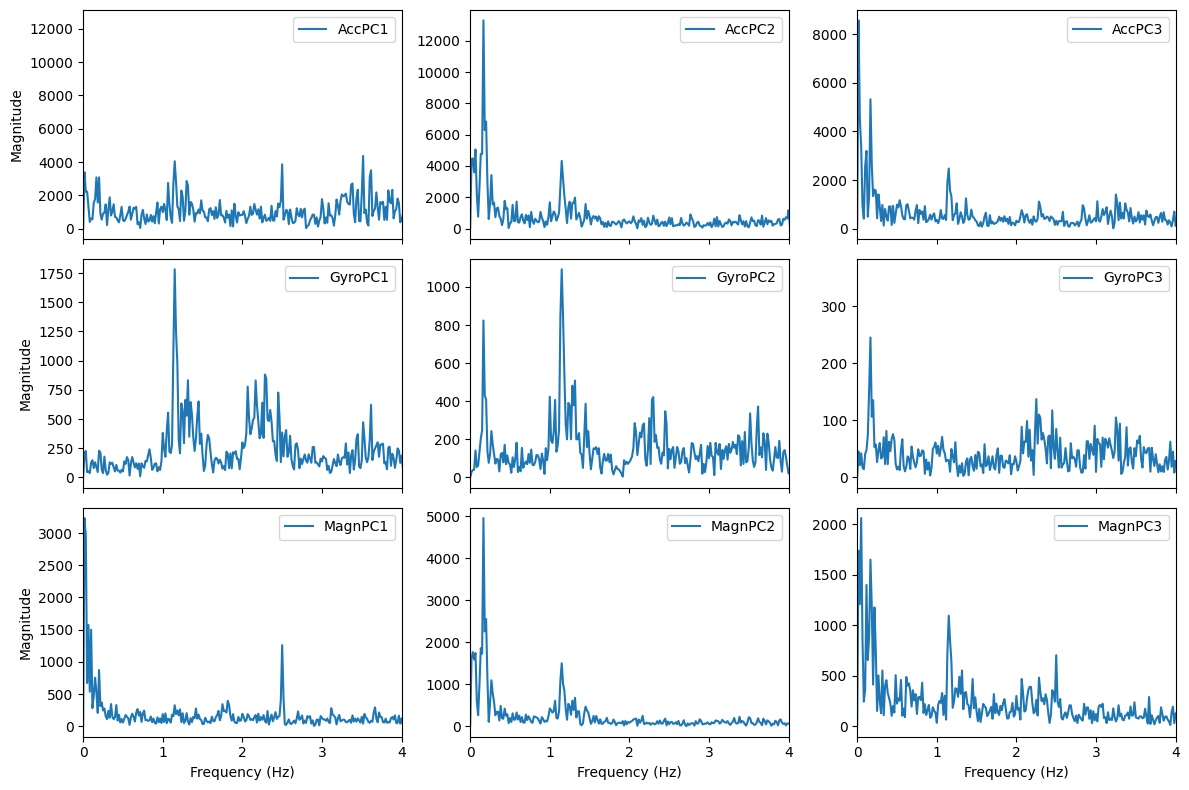

In [ ]:
# Create 3x3 subplots for each PCA component
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True)
axes = axes.flatten()
for i, (ylabel, cols) in enumerate(label_columns_pairs.items()):
    for j, col in enumerate(cols):
        ax = axes[i * 3 + j]
        
        signal = df1[col].values
        signal = detrend(signal) # Detrend the signal
        
        # Compute the Fourier Transform of the signal
        fft_result = fft(signal)
        
        # Compute the corresponding frequency axis
        n = len(signal)
        freqs = fftfreq(n, d=1./ds1_log_freq)
        
        # Compute the magnitude of the Fourier spectrum (only positive frequencies)
        magnitude = np.abs(fft_result)[:n//2]
        freqs = freqs[:n//2]
    
        # Set y-axis label only on the leftmost column
        if j == 0:
            ax.set_ylabel("Magnitude")
        
        # Set x-axis label only on the bottommost row
        if i == 2:
            ax.set_xlabel("Frequency (Hz)")
        
        ax.set_xlim([0, 4])
        ax.plot(freqs, magnitude)
        ax.legend([col], loc="upper right")

plt.tight_layout()
plt.show()

It is evident from the frequency domain plot that the peak around 0.2 Hz corresponds to the respiratory rate (RR), while the peak around 1 Hz is associated with the heart rate (HR). Interestingly, depending on the direction, either the RR or HR peak may not be visible.

Next, we proceed with recovering the signal using multiple methods. While we could directly measure the period from the Fourier spectrum, we opt to reconstruct the signal for further analysis.

To avoid correlations, we recover the signal from a single component of each sensor type (Acc, Gyro, and Magn). Specifically, we select AccPC2, GyroPC2 (or GyroPC3 ?), and MagnPC2, as these components exhibit a stronger signal at the frequencies of interest.

### Notes on AI usage



used for language, browsing through library functions, documentation generation

any result has been critically reviewed and we take full responsibility